# Univariate Random Variables and Distributions

This notebook focuses primarily on continuous random variables. It introduces population distributions, quantiles and moments, then distinguishes those theoretical properties from the empirical quantities calculated from a finite sample. Gaussian examples make the definitions concrete, alongside Student-t, Laplace and skew-normal distributions.

Notebook 00 introduced returns, losses and the financial questions. Here I develop the distributional properties needed to answer them. Expectation and variance remain properties of any random variable, including a return, without requiring a loss interpretation. Notebook 02 develops the multivariate framework through bivariate illustrations, and Notebook 03 studies uncertainty when population parameters are estimated.

Throughout these examples, $X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$ is a simplifying sampling framework. Financial returns need not be fully IID because dependence over time can matter. The time-series notebooks address that distinction.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from finstats.distributions import student_t_variance, student_t_kurtosis
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from finstats.risk import gaussian_var, gaussian_es, student_t_var, student_t_es


## 1. Cumulative Distribution Function and Probability Density Function

Let $X$ denote a random variable and $x\in\mathcal X\subseteq\mathbb R$ a possible realization. Tomorrow's asset price is uncertain today, whereas the price observed tomorrow is a number. Discrete variables have countable support, but the focus here is on continuous variables with densities.

The cumulative distribution function is
$$F_X(t)=P(X\le t),\qquad t\in\mathbb R.$$
It characterizes the distribution, is nondecreasing and has limits zero and one at the ends of the real line. In particular,
$$P(a<X\le b)=F_X(b)-F_X(a).$$

For an absolutely continuous distribution, the density and CDF satisfy
$$f_X(x)=\frac{\partial F_X(x)}{\partial x},\qquad
F_X(x)=\int_{-\infty}^{x}f_X(t)\,dt.$$
The derivative holds where the CDF is differentiable. The density is nonnegative and integrates to one. Its value at a point is not a probability and can exceed one. Interval probabilities are areas:
$$P(a<X\le b)=\int_a^b f_X(x)\,dx.$$
A single point has probability zero. The PDF and CDF describe the same distribution.

For illustration, I use $X\sim N(0,1)$. The density area between $-1$ and $1$ equals the increase in the CDF over that interval.

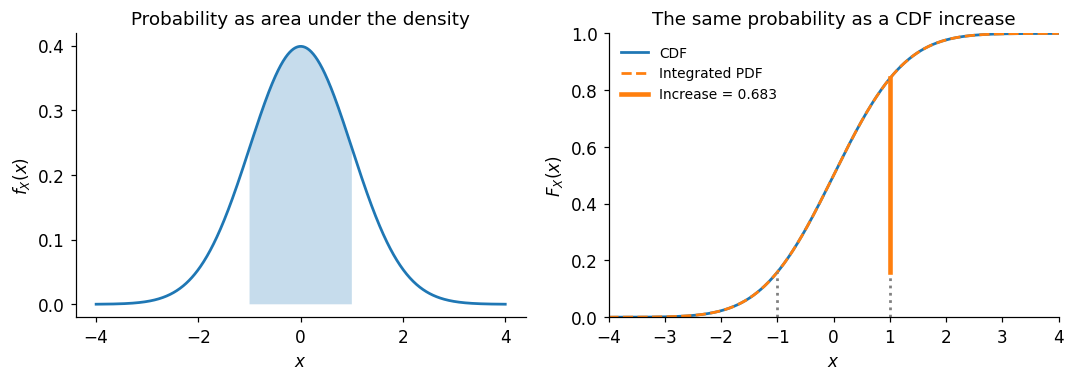

P(−1 < X ≤ 1) = 0.6827


In [2]:
grid = np.linspace(-4, 4, 1001)
a, b = -1.0, 1.0
probability = stats.norm.cdf(b) - stats.norm.cdf(a)
integration_grid = np.linspace(-8, 8, 4001)
density = stats.norm.pdf(integration_grid)
cdf_integral = stats.norm.cdf(-8) + cumulative_trapezoid(density, integration_grid, initial=0)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(grid, stats.norm.pdf(grid))
axes[0].fill_between(grid, stats.norm.pdf(grid), where=(grid >= a) & (grid <= b), alpha=.25)
axes[0].set(xlabel="$x$", ylabel="$f_X(x)$", title="Probability as area under the density")
axes[1].plot(integration_grid, stats.norm.cdf(integration_grid), label="CDF")
axes[1].plot(integration_grid, cdf_integral, "--", label="Integrated PDF")
for v in (a, b):
    axes[1].plot([v, v], [0, stats.norm.cdf(v)], ":", color="0.5")
axes[1].plot([b, b], [stats.norm.cdf(a), stats.norm.cdf(b)], color="C1", linewidth=3,
             label=f"Increase = {probability:.3f}")
axes[1].set(xlim=(-4, 4), ylim=(0, 1), xlabel="$x$", ylabel="$F_X(x)$",
            title="The same probability as a CDF increase")
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()
print(f"P(−1 < X ≤ 1) = {probability:.4f}")

## 2. Quantiles and Risk Measurement

Quantiles locate outcomes within a distribution. Applied to losses, they also provide thresholds for measuring downside risk.

### Quantiles

If $F_X$ is continuous and strictly increasing, its inverse gives
$$x_q=F_X^{-1}(q),\qquad 0<q<1,\qquad P(X\le x_q)=q.$$
When the CDF is not strictly increasing, define the generalized quantile by
$$F_X^{-}(q)=\inf\{x:F_X(x)\ge q\}.$$
This definition remains meaningful when a continuous CDF has flat regions, selecting the leftmost threshold where cumulative probability reaches $q$. The first, second, and third quartiles are $x_{0.25},x_{0.50},x_{0.75}$, with $x_{0.50}$ the median. Exact equal-probability partitions require a continuous distribution.

For illustration, I use the third quartile of $N(0,1)$. The density area to its left is $0.75$, which is the height of the CDF at that quantile.

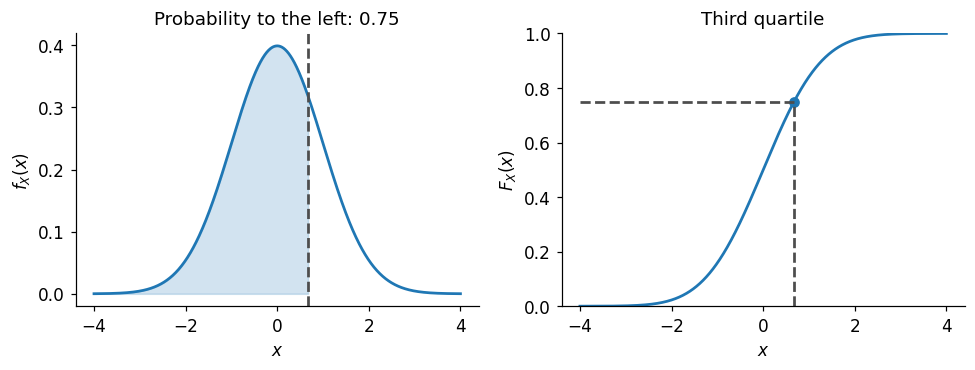

Third quartile = 0.6745, CDF = 0.7500


In [3]:
q = .75
x_q = stats.norm.ppf(q)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(grid, stats.norm.pdf(grid), color="C0")
axes[0].fill_between(grid, stats.norm.pdf(grid), where=grid <= x_q, color="C0", alpha=.2)
axes[0].axvline(x_q, color="0.3", linestyle="--")
axes[0].set(xlabel="$x$", ylabel="$f_X(x)$", title="Probability to the left: 0.75")
axes[1].plot(grid, stats.norm.cdf(grid), color="C0")
axes[1].plot([x_q, x_q], [0, q], "--", color="0.3")
axes[1].plot([-4, x_q], [q, q], "--", color="0.3")
axes[1].scatter([x_q], [q], color="C0")
axes[1].set(xlabel="$x$", ylabel="$F_X(x)$", title="Third quartile", ylim=(0, 1))
fig.tight_layout()
plt.show()
print(f"Third quartile = {x_q:.4f}, CDF = {stats.norm.cdf(x_q):.4f}")

### Value at Risk and Expected Shortfall

For the simple net return $R$, the relative loss is $L=-R$, as introduced in Notebook 00. A negative return therefore becomes a positive loss. Quantiles describe tail thresholds, while expectations describe average outcomes. Section 3 defines expectation formally; here, the conditional expectation means the average loss among outcomes beyond the threshold.

**Value at Risk (VaR)** is the loss quantile of order $1-\alpha$:
$$VaR_\alpha=F_L^{-1}(1-\alpha).$$
For a continuous loss distribution, $P(L>VaR_\alpha)=\alpha$. Thus 5% VaR marks the threshold exceeded in the worst 5% of outcomes, rather than a maximum possible loss.

**Expected Shortfall (ES)** is the average loss beyond that threshold, when finite:
$$ES_\alpha=E[L\mid L>VaR_\alpha]
=\frac1\alpha\int_{VaR_\alpha}^\infty l f_L(l)\,dl
=\frac1\alpha\int_{1-\alpha}^1F_L^{-1}(q)\,dq.$$
The final equality follows from $q=F_L(l)$. Because ES averages losses beyond the threshold, $ES_\alpha\geq VaR_\alpha$.

Here $\alpha$ denotes the tail probability. These are population quantities under a specified model. Notebook 04 considers their empirical estimates, where finite samples and probability at the quantile boundary require care.

For example, if $L\sim N(0,1)$ describes losses directly, its 95th quantile is also its 5% VaR:
$$VaR_{0.05}=F_L^{-1}(0.95)=\Phi^{-1}(0.95)\approx1.645.$$
The threshold has the same units as $L$. Defining the variable as a loss makes the upper quantile a downside-risk measure. If instead $R$ describes returns, $L=-R$ gives $VaR_\alpha(L)=-F_R^{-1}(\alpha)$ for a continuous strictly increasing CDF.

The shaded area below is the upper 5% of the Gaussian loss distribution. VaR marks where this tail begins, while ES marks its average loss. Losses are measured in standard-deviation units.

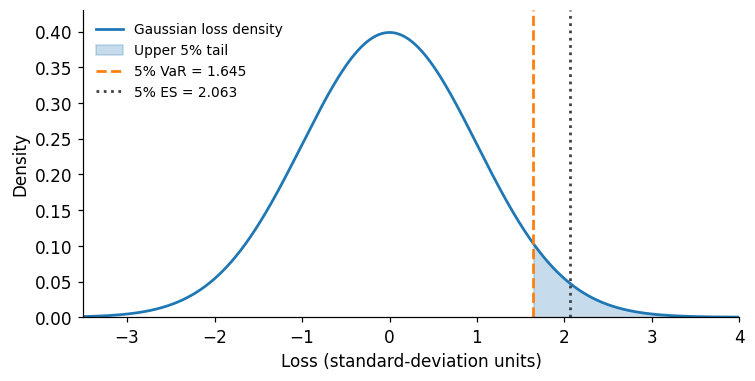

In [4]:
loss_grid = np.linspace(-3.5, 4, 1501)
var_05 = gaussian_var(0, 1, .05)
es_05 = gaussian_es(0, 1, .05)
fig, ax = plt.subplots(figsize=(7, 3.6))
loss_density = stats.norm.pdf(loss_grid)
ax.plot(loss_grid, loss_density, color="C0", label="Gaussian loss density")
ax.fill_between(loss_grid, 0, loss_density, where=loss_grid >= var_05,
                color="C0", alpha=.25, label="Upper 5% tail")
ax.axvline(var_05, color="C1", linestyle="--", label=f"5% VaR = {var_05:.3f}")
ax.axvline(es_05, color="0.25", linestyle=":", label=f"5% ES = {es_05:.3f}")
ax.set(xlabel="Loss (standard-deviation units)", ylabel="Density", xlim=(-3.5, 4),
       ylim=(0, .43))
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 3. Theoretical Moments

Moments summarize the location, dispersion and shape of a population distribution. Sample counterparts estimate these properties from finite observations.

### Population Moments

When $E[|X|]<\infty$, the theoretical expectation is
$$\mu=E[X]=\int_{\mathbb R}x f_X(x)\,dx.$$
For a finite second moment, the variance and standard deviation are
$$\sigma^2=\operatorname{Var}(X)=E[(X-\mu)^2]=E[X^2]-\mu^2,\qquad \sigma=\sqrt{\sigma^2}.$$
The identity follows by expanding the squared deviation and taking expectations. These are population quantities, rather than values of a particular realization. Under a Gaussian model, $\mu$ and $\sigma^2$ specify the entire distribution.

### Higher Moments, Skewness and Kurtosis

The $k$th raw moment is $E[X^k]$ and the $k$th central moment is $E[(X-\mu)^k]$, when the corresponding absolute moment is finite. If $0<\sigma^2<\infty$, standardized moments describe shape independently of units:
$$Sk(X)=E\left[\left(\frac{X-E[X]}{\sigma}\right)^3\right],$$
$$Kur(X)=E\left[\left(\frac{X-E[X]}{\sigma}\right)^4\right],\qquad
Kur_{\mathrm{excess}}(X)=Kur(X)-3.$$
Positive skewness indicates right asymmetry and negative skewness left asymmetry. Zero skewness does not establish symmetry for every distribution. The Gaussian benchmark is $Sk(X)=0$ and $Kur(X)=3$.

Kurtosis weights large standardized deviations to the fourth power. A higher value signals a larger fourth moment and often greater tail weight, but is not a full ordering of tail probabilities. It cannot be used when the fourth moment is not finite.

Mean and variance describe expected return and dispersion. Two return distributions with those same quantities can differ in the frequency and direction of large movements. Skewness and kurtosis add shape information, although four moments still do not identify a general distribution.

### Empirical Moments

In practice, the population distribution is unknown. A proposed parametric family remains an assumption, and the observations $x_1,\ldots,x_n$ form one finite realization. Their empirical raw and central moments are
$$\widehat m'_k=\frac1n\sum_{i=1}^n x_i^k,\qquad
m_k=\frac1n\sum_{i=1}^n(x_i-\bar x_n)^k.$$
In particular,
$$\bar x_n=\frac1n\sum_{i=1}^n x_i,\qquad
m_2=\frac1n\sum_{i=1}^n(x_i-\bar x_n)^2,$$
$$s_n^2=\frac1{n-1}\sum_{i=1}^n(x_i-\bar x_n)^2=\frac{n}{n-1}m_2,\qquad n>1.$$
Both $m_2$ and $s_n^2$ are sample quantities. Under IID sampling with finite variance, the $n-1$ denominator makes the sample variance unbiased for the population variance. Notebook 03 defines unbiasedness as a property of an estimator across possible samples. Neither generally equals $\sigma^2$ in a realized sample.

The empirical skewness and raw kurtosis used here are $m_3/m_2^{3/2}$ and $m_4/m_2^2$, when $m_2>0$. They need not equal the population standardized moments.

For illustration, I draw nested IID samples of size $20$, $100$ and $1000$ from $N(0,1)$ with seed 112. The same population underlies each histogram. The table compares empirical moments with their theoretical targets. Larger samples generally bring these quantities closer to the population values, although agreement need not improve monotonically in a particular realization.

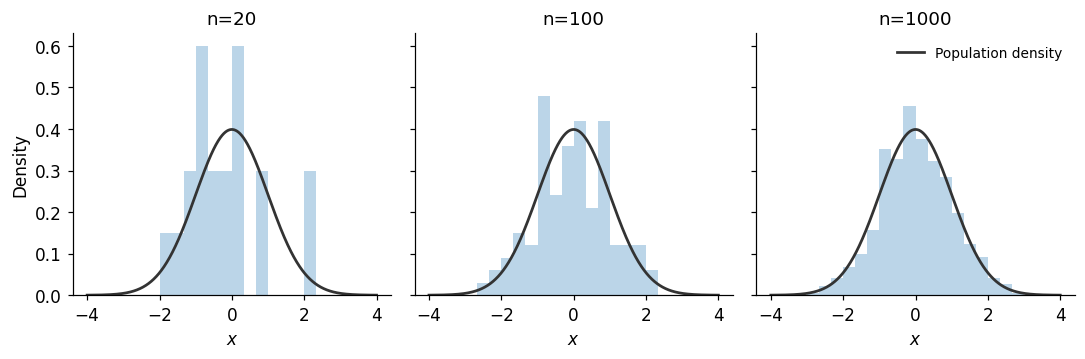

,Mean,Second central moment (n),Variance (n−1),Skewness,Raw kurtosis
n=20,-0.190360,1.128960,1.188379,0.835314,3.131461
n=100,-0.040645,1.057632,1.068315,0.039730,2.434956
n=1000,0.022418,0.979060,0.980040,0.047918,2.913473
Population,0.000000,1.000000,1.000000,0.000000,3.000000


In [5]:
draw = np.random.default_rng(112).normal(size=1000)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharex=True, sharey=True)
rows = []
for ax, n in zip(axes, (20, 100, 1000)):
    values = draw[:n]
    ax.hist(values, bins=np.linspace(-4, 4, 25), density=True, color="C0", alpha=.3)
    ax.plot(grid, stats.norm.pdf(grid), color="0.2", label="Population density")
    ax.set(title=f"n={n}", xlabel="$x$")
    rows.append([sample_mean(values), sample_variance(values, ddof=0), sample_variance(values), sample_skewness(values), sample_kurtosis(values)])
axes[0].set_ylabel("Density")
axes[-1].legend(fontsize=9)
fig.tight_layout()
plt.show()
display(pd.DataFrame(rows + [[0, 1, 1, 0, 3]], index=["n=20", "n=100", "n=1000", "Population"], columns=["Mean", "Second central moment (n)", "Variance (n−1)", "Skewness", "Raw kurtosis"]))

## 4. Examples of Univariate Distributions

A parametric family specifies a density through a small number of parameters. If a family is assumed for financial observations, these parameters are unknown quantities to estimate from data. Here I define the families and their population properties, without fitting them.

### Gaussian Distribution

The Gaussian model describes symmetric outcomes using a location and a variance parameter.

$$X\sim N(\mu,\sigma^2),\qquad
f_X(x)=\frac1{\sigma\sqrt{2\pi}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].$$
The parameter domains are $\mu\in\mathbb R$ and $\sigma^2\in(0,\infty)$, which are the population mean and variance. The density is symmetric, with skewness zero and kurtosis three.

#### Risk Measures for Gaussian Losses

For $L=\mu_L+\sigma_LZ$ with $Z\sim N(0,1)$ and $z=\Phi^{-1}(1-\alpha)$,
$$VaR_\alpha=\mu_L+\sigma_Lz.$$
Using $\phi'(u)=-u\phi(u)$ gives
$$\int_z^\infty u\phi(u)\,du=\phi(z),\qquad
ES_\alpha=\mu_L+\sigma_L\frac{\phi(z)}\alpha.$$
The same formula applies to fitted Gaussian losses after substituting parameter estimates. Known parameters give a population quantity, while estimated parameters give an estimate.

### Student-t Distribution

For degrees of freedom $\nu\in(0,\infty)$, the standard Student-t density is
$$f_X(x)=\frac{\Gamma((\nu+1)/2)}{\sqrt{\nu\pi}\Gamma(\nu/2)}
\left(1+\frac{x^2}{\nu}\right)^{-(\nu+1)/2}.$$
Its density is symmetric and approaches the standard Gaussian as $\nu$ increases. The location-scale family $t(\mu,\lambda,\nu)$ has density
$$f_Y(y;\mu,\lambda,\nu)=\frac{\Gamma((\nu+1)/2)}{\lambda\sqrt{\nu\pi}\Gamma(\nu/2)}
\left(1+\frac{(y-\mu)^2}{\lambda^2\nu}\right)^{-(\nu+1)/2},\qquad\lambda>0.$$
Its population properties are
$$E[Y]=\mu\quad(\nu>1),\qquad \operatorname{Var}(Y)=\frac{\lambda^2\nu}{\nu-2}\quad(\nu>2),$$
$$Sk(Y)=0\quad(\nu>3),\qquad Kur(Y)=3+\frac6{\nu-4}\quad(\nu>4).$$
The scale $\lambda$ is not the standard deviation. A $k$th absolute moment exists only for $\nu>k$, so symmetry alone does not guarantee a finite mean or skewness. For example, $t_1$ has no finite mean, while $t_3$ has finite variance but no finite fourth moment.

The parameters to estimate are location $\mu\in\mathbb R$, scale $\lambda\in(0,\infty)$ and degrees of freedom $\nu\in(0,\infty)$. Degrees of freedom need not be integers.

#### Risk Measures for Student-t Losses

For $L=m+\lambda T_\nu$, with $t=t_{1-\alpha,\nu}$,
$$VaR_\alpha=m+\lambda t.$$
Integrating the density above gives
$$\int_t^\infty u f_{t_\nu}(u)\,du=\frac{\nu+t^2}{\nu-1}f_{t_\nu}(t),$$
so
$$ES_\alpha=m+\lambda\frac{\nu+t^2}{\nu-1}\frac{f_{t_\nu}(t)}\alpha,\qquad\nu>1.$$
A quantile exists for every $\nu>0$, but finite ES requires $\nu>1$. At $\nu=2$, ES is finite even though variance is infinite. Scale $\lambda$ is not the standard deviation.

### Laplace Distribution

For $\mu\in\mathbb R$ and $\lambda\in(0,\infty)$,
$$f_Y(y;\mu,\lambda)=\frac1{2\lambda}\exp\left(-\frac{|y-\mu|}{\lambda}\right),$$
$$E[Y]=\mu,\qquad \operatorname{Var}(Y)=2\lambda^2.$$
It is symmetric with a sharp central peak and exponential tails. All moments exist, with $Sk(Y)=0$ and $Kur(Y)=6$. The tails decay more slowly than Gaussian tails, but faster than Student-t polynomial tails.

The parameters to estimate are location $\mu\in\mathbb R$ and scale $\lambda\in(0,\infty)$.

### Standard Skew-Normal Distribution

For $X\sim SN(0,1,\alpha)$, with $\alpha\in\mathbb R$,
$$f_X(x;\alpha)=2\phi(x)\Phi(\alpha x),\qquad x\in\mathbb R.$$
Here $\phi$ and $\Phi$ are the standard Gaussian density and CDF. The shape parameter $\alpha\in\mathbb R$ controls asymmetry. Here $\alpha$ denotes skew-normal shape, not the tail probability used in Section 2. Location and scale are fixed at zero and one in this standard form. At $\alpha=0$, the density is standard Gaussian. With $\delta=\alpha/\sqrt{1+\alpha^2}$,
$$E[X]=\delta\sqrt{2/\pi},\qquad \operatorname{Var}(X)=1-2\delta^2/\pi.$$
Thus the standard location and scale labels do not imply a zero mean or unit variance when $\alpha\ne0$.

### Illustrating the Univariate Distributions

For illustration, I compare the four families below. The Gaussian panel shows the effect of mean and variance. The Student-t panel shows convergence towards a Gaussian as $\nu$ increases. The Laplace comparison holds variance at two. The skew-normal panel uses $\alpha=-3,0,3$.

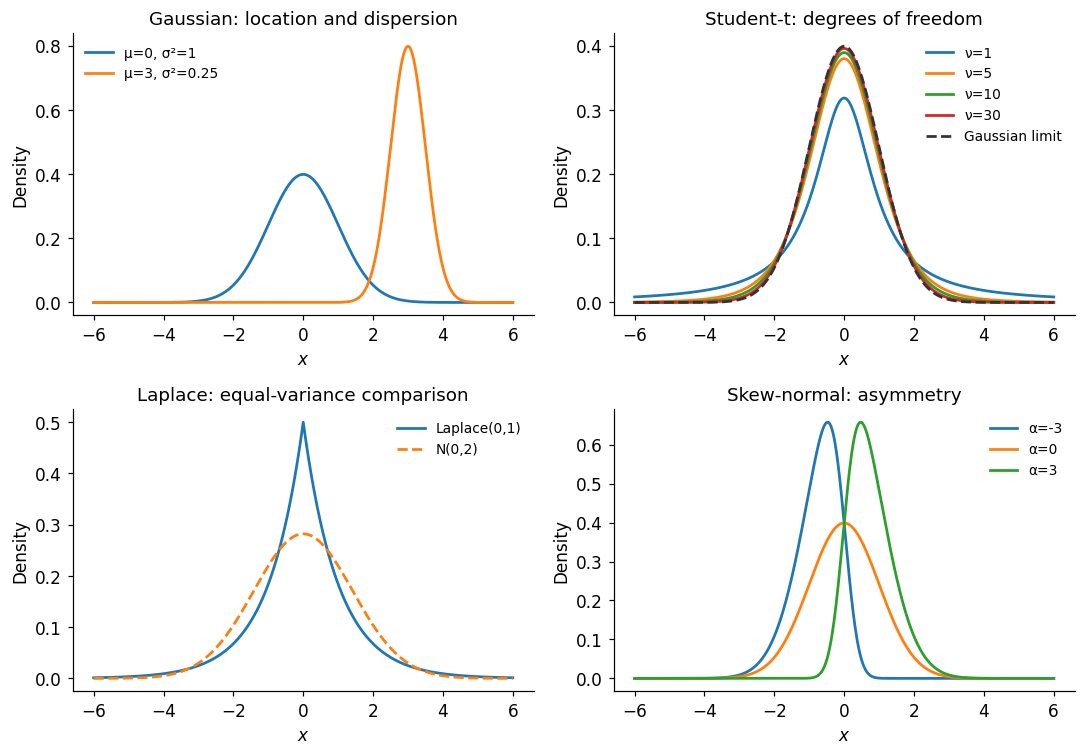

,Population variance,Population raw kurtosis
ν,,
1,NaN,NaN
5,1.666667,9.000000
10,1.250000,4.000000
30,1.071429,3.230769


NaN marks a moment that is not finite.


In [6]:
family_grid = np.linspace(-6, 6, 1201)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for mu, sigma in ((0, 1), (3, .5)):
    axes[0, 0].plot(family_grid, stats.norm.pdf(family_grid, mu, sigma), label=f"μ={mu}, σ²={sigma**2:g}")
for nu in (1, 5, 10, 30):
    axes[0, 1].plot(family_grid, stats.t.pdf(family_grid, nu), label=f"ν={nu}")
axes[0, 1].plot(family_grid, stats.norm.pdf(family_grid), "--", color="0.2", label="Gaussian limit")
axes[1, 0].plot(family_grid, stats.laplace.pdf(family_grid), label="Laplace(0,1)")
axes[1, 0].plot(family_grid, stats.norm.pdf(family_grid, scale=np.sqrt(2)), "--", label="N(0,2)")
for alpha in (-3, 0, 3):
    axes[1, 1].plot(family_grid, stats.skewnorm.pdf(family_grid, alpha), label=f"α={alpha}")
for ax, title in zip(axes.flat, ("Gaussian: location and dispersion", "Student-t: degrees of freedom", "Laplace: equal-variance comparison", "Skew-normal: asymmetry")):
    ax.set(xlabel="$x$", ylabel="Density", title=title)
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
display(pd.DataFrame({
    "Population variance": [student_t_variance(nu) if nu > 2 else np.nan for nu in (1, 5, 10, 30)],
    "Population raw kurtosis": [student_t_kurtosis(nu) if nu > 4 else np.nan for nu in (1, 5, 10, 30)],
}, index=pd.Index((1, 5, 10, 30), name="ν")))
print("NaN marks a moment that is not finite.")

### Illustrating Tail Risk across the Four Distributions

The same four families can describe losses. For comparison, I center and scale each to mean zero and variance one: Gaussian, Student-$t_5$ with scale $\sqrt{3/5}$, Laplace with scale $1/\sqrt2$, and skew-normal with shape three before centering and scaling. The skew-normal shape here refers to losses, rather than returns.

Each panel shows the upper 5% tail, its VaR threshold and its ES. Common axes make the tail differences visible even though mean and variance agree. The table gives their population risk measures at 5% and 1%.

,family,alpha,VaR,ES
0,Gaussian,0.05,1.6449,2.0627
1,Gaussian,0.01,2.3263,2.6652
2,Student-t₅,0.05,1.5608,2.2387
3,Student-t₅,0.01,2.6065,3.4488
4,Laplace,0.05,1.6282,2.3353
5,Laplace,0.01,2.7662,3.4733
6,Skew-normal,0.05,1.8409,2.4191
7,Skew-normal,0.01,2.7834,3.2671


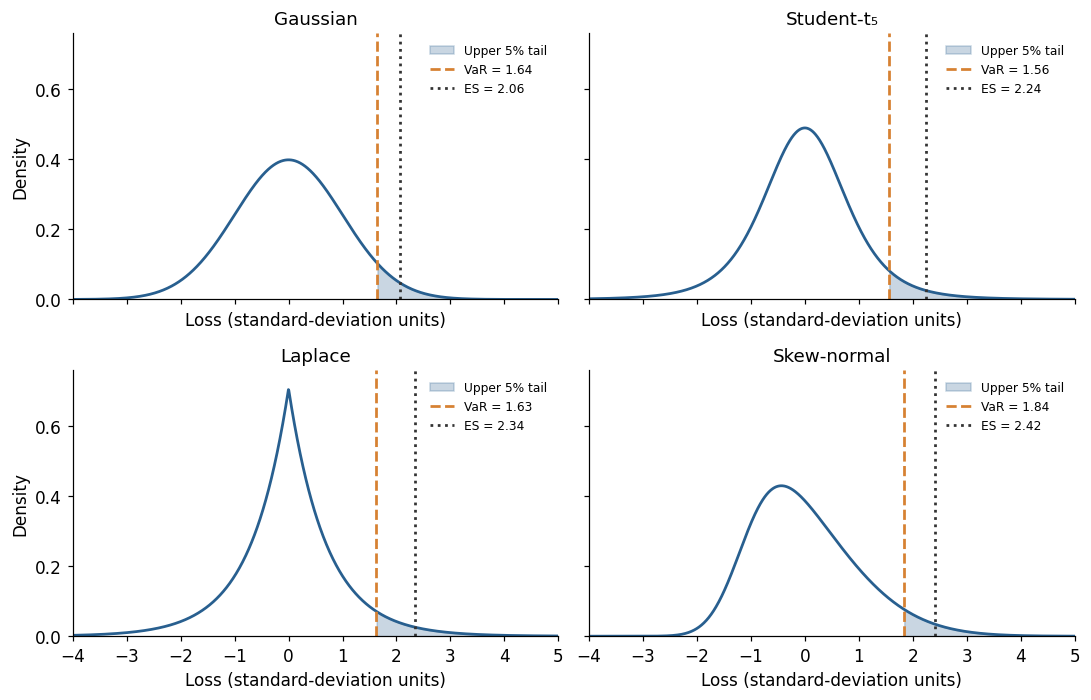

In [7]:
skew_mean, skew_variance = stats.skewnorm.stats(3, moments="mv")
loss_populations = {
    "Gaussian": stats.norm(),
    "Student-t₅": stats.t(5, scale=np.sqrt(3/5)),
    "Laplace": stats.laplace(scale=1/np.sqrt(2)),
    "Skew-normal": stats.skewnorm(3, loc=-skew_mean/np.sqrt(skew_variance), scale=1/np.sqrt(skew_variance)),
}
population_rows = []
for name, distribution in loss_populations.items():
    for alpha in (.05, .01):
        if name == "Gaussian":
            var, es = gaussian_var(0, 1, alpha), gaussian_es(0, 1, alpha)
        elif name == "Student-t₅":
            var, es = student_t_var(0, np.sqrt(3/5), 5, alpha), student_t_es(0, np.sqrt(3/5), 5, alpha)
        else:
            var = distribution.isf(alpha)
            es = quad(lambda x: x*distribution.pdf(x), var, np.inf)[0]/alpha
        population_rows.append({"family": name, "alpha": alpha, "VaR": var, "ES": es})
population_risk = pd.DataFrame(population_rows)
display(population_risk.round(4))
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True, sharey=True)
loss_grid = np.linspace(-4, 5, 1201)
for ax, name in zip(axes.flat, loss_populations):
    distribution = loss_populations[name]
    risk = population_risk.loc[(population_risk["family"] == name) &
                               (population_risk["alpha"] == .05)].iloc[0]
    density = distribution.pdf(loss_grid)
    ax.plot(loss_grid, density, color="#285f8f")
    ax.fill_between(loss_grid, 0, density, where=loss_grid >= risk["VaR"],
                    color="#285f8f", alpha=.25, label="Upper 5% tail")
    ax.axvline(risk["VaR"], color="#d68132", linestyle="--",
               label=f"VaR = {risk['VaR']:.2f}")
    ax.axvline(risk["ES"], color="#333333", linestyle=":",
               label=f"ES = {risk['ES']:.2f}")
    ax.set(title=name, xlabel="Loss (standard-deviation units)", xlim=(-4, 5), ylim=(0, .76))
    ax.legend(fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Density")
fig.tight_layout()
plt.show()

The same mean and variance can coexist with different VaR thresholds and tail expectations. ES describes the severity beyond each model’s own 5% threshold, not beyond a common loss value. The skew-normal example also shows why the direction of asymmetry matters for downside risk.

For returns, a population mean describes expected return and a population standard deviation describes volatility at a given horizon. An observed average or variance describes the finite sample instead.

These parametric models have theoretical properties, but their empirical counterparts generally differ in finite samples. Notebook 02 extends the population–sample distinction to bivariate and multivariate distributions. Notebook 03 then asks how to estimate unknown parameters and describe the uncertainty.